# LLaVA Cross-Modal Attention Probing

**核心问题**：在 LLaVA 内部，图像 patch token 和文字 token 之间的 attention 强度，在讽刺表情包和普通表情包之间有什么差异？

**数据集**：MMSD 2.0（Twitter 图文讽刺检测，label=1 表示讽刺）

**实验**：
1. 提取每层每个 attention head 的权重矩阵
2. 分离图像 token 区段和文字 token 区段
3. 计算「图→文」和「文→图」的平均 attention 强度
4. 对比讽刺 vs 非讽刺样本，画热图和统计显著性

In [1]:
# ── 安装依赖 ─────────────────────────────────────────────────────────────────
!pip install -q transformers>=4.36.0 accelerate bitsandbytes datasets
!pip install -q matplotlib seaborn scipy tqdm Pillow

zsh:1: 4.36.0 not found


In [2]:
# ── 导入 ─────────────────────────────────────────────────────────────────────
import os, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from datasets import load_dataset
from scipy import stats
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration, BitsAndBytesConfig

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
os.makedirs('artifacts/probing', exist_ok=True)
os.makedirs('results/probing', exist_ok=True)

Device: cpu


## 1. 加载 LLaVA 模型

In [ ]:
# ── LLaVA-1.6-Mistral-7B，4-bit 量化 ────────────────────────────────────────
# 显存需求约 8GB；如果是 CPU 或显存不足，可以换 llava-hf/llava-1.5-7b-hf
MODEL_ID = 'llava-hf/llava-v1.6-mistral-7b-hf'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
)

# transformers >= 4.45 移除了 LlavaNextProcessor 的 image_token 参数
# 用 AutoProcessor 绕过版本差异，功能完全一致
from transformers import AutoProcessor
processor = AutoProcessor.from_pretrained(MODEL_ID)

model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
)
model.eval()

num_layers = model.language_model.config.num_hidden_layers
num_heads  = model.language_model.config.num_attention_heads
print(f'模型加载完成：{MODEL_ID}')
print(f'LLaMA 层数: {num_layers}，attention heads: {num_heads}')

## 2. 加载 MMSD 2.0 数据集

In [ ]:
# ── 加载数据，平衡采样讽刺/非讽刺 ───────────────────────────────────────────
hf = load_dataset('coderchen01/MMSD2.0', 'mmsd-v2')
test_split = hf['test']

print(f'测试集总量: {len(test_split)}')
print(f'  讽刺 (label=1): {sum(1 for x in test_split["label"] if x==1)}')
print(f'  非讽刺 (label=0): {sum(1 for x in test_split["label"] if x==0)}')

# 每类各取 N_PER_CLASS 个样本
N_PER_CLASS = 50
random.seed(42)

sarc_idx  = [i for i, x in enumerate(test_split['label']) if x == 1]
nosarc_idx = [i for i, x in enumerate(test_split['label']) if x == 0]
sarc_idx   = random.sample(sarc_idx,   min(N_PER_CLASS, len(sarc_idx)))
nosarc_idx = random.sample(nosarc_idx, min(N_PER_CLASS, len(nosarc_idx)))

samples = [(test_split[i], 1) for i in sarc_idx] + \
          [(test_split[i], 0) for i in nosarc_idx]
random.shuffle(samples)
print(f'\n采样: {N_PER_CLASS} 讽刺 + {N_PER_CLASS} 非讽刺 = {len(samples)} 样本')

## 3. 提取 Attention 权重

### 关键：如何定位图像 token 和文字 token 的位置

LLaVA 的 token 序列结构：
```
[INST]  <image_patch_tokens × 576>  \n  {text_tokens}  [/INST]
```
- `<image>` 占位符会被展开为 576 个 patch token（ViT-B/32 的 24×24 patch grid）
- 我们通过 `input_ids` 中 `image_token_index` 的位置来定位图像区段

In [ ]:
# ── 提取单个样本的 attention 权重，并返回图像/文字 token 的位置范围 ──────────
PROMPT_TEMPLATE = '[INST] <image>\n{text} [/INST]'

# LLaVA-1.6 的 image_token_index（对应 <image> 特殊 token）
IMAGE_TOKEN_ID = processor.tokenizer.convert_tokens_to_ids('<image>')
print(f'IMAGE_TOKEN_ID: {IMAGE_TOKEN_ID}')

def extract_cross_modal_attention(row):
    """
    返回:
      attn_img2txt: (num_layers, num_heads) — 每层每个 head 的图→文平均 attention
      attn_txt2img: (num_layers, num_heads) — 文→图平均 attention
      img_span: (start, end) image token 区段
      txt_span: (start, end) text token 区段
    """
    prompt = PROMPT_TEMPLATE.format(text=row['text'])
    inputs = processor(
        text=prompt,
        images=row['image'].convert('RGB'),
        return_tensors='pt'
    ).to(device)

    input_ids = inputs['input_ids'][0]  # (seq_len,)

    # 定位图像 token 区段（连续的 IMAGE_TOKEN_ID）
    img_positions = (input_ids == IMAGE_TOKEN_ID).nonzero(as_tuple=True)[0]
    if len(img_positions) == 0:
        # 有些版本展开后不再保留 IMAGE_TOKEN_ID，用 image_token_index 属性
        img_token_idx = getattr(model.config, 'image_token_index', 32000)
        img_positions = (input_ids == img_token_idx).nonzero(as_tuple=True)[0]

    img_start = int(img_positions[0])
    img_end   = int(img_positions[-1]) + 1  # exclusive

    # 文字 token：图像区段之后的非特殊 token
    # 简单策略：img_end 之后到序列末尾（包含文字 + [/INST]）
    txt_start = img_end
    txt_end   = len(input_ids)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # attentions: list of (1, num_heads, seq_len, seq_len) per layer
    attn_img2txt = np.zeros((num_layers, num_heads))
    attn_txt2img = np.zeros((num_layers, num_heads))

    for layer_i, layer_attn in enumerate(outputs.attentions):
        a = layer_attn[0].float().cpu().numpy()  # (heads, seq, seq)
        # 图→文：query=图像区段，key=文字区段
        attn_img2txt[layer_i] = a[:, img_start:img_end, txt_start:txt_end].mean(axis=(1, 2))
        # 文→图：query=文字区段，key=图像区段
        attn_txt2img[layer_i] = a[:, txt_start:txt_end, img_start:img_end].mean(axis=(1, 2))

    return attn_img2txt, attn_txt2img, (img_start, img_end), (txt_start, txt_end)

print('函数定义完成。')

In [ ]:
# ── 批量提取并缓存 ────────────────────────────────────────────────────────────
CACHE = 'artifacts/probing/cross_modal_attn.npz'

if os.path.exists(CACHE):
    print('加载缓存...')
    d = np.load(CACHE)
    all_img2txt = d['img2txt']  # (N, layers, heads)
    all_txt2img = d['txt2img']  # (N, layers, heads)
    all_labels  = d['labels']   # (N,)
    print(f'加载完成: {all_img2txt.shape}')
else:
    print(f'提取 {len(samples)} 个样本的 attention 权重...')
    img2txt_list, txt2img_list, label_list = [], [], []
    errors = 0

    for row, label in tqdm(samples):
        try:
            i2t, t2i, _, _ = extract_cross_modal_attention(row)
            img2txt_list.append(i2t)
            txt2img_list.append(t2i)
            label_list.append(label)
        except Exception as e:
            errors += 1
            print(f'  跳过一个样本: {e}')

    all_img2txt = np.stack(img2txt_list)  # (N, layers, heads)
    all_txt2img = np.stack(txt2img_list)
    all_labels  = np.array(label_list)

    np.savez(CACHE, img2txt=all_img2txt, txt2img=all_txt2img, labels=all_labels)
    print(f'完成，跳过 {errors} 个错误样本，保存 shape: {all_img2txt.shape}')

## 4. 讽刺 vs 非讽刺 Cross-Modal Attention 对比

In [ ]:
# ── 按标签分组，计算每层的平均 cross-modal attention ─────────────────────────
sarc_mask  = all_labels == 1
nosarc_mask = all_labels == 0

# 在 heads 维度上取平均 → (N, layers)
img2txt_mean_heads = all_img2txt.mean(axis=2)  # (N, layers)
txt2img_mean_heads = all_txt2img.mean(axis=2)

sarc_i2t   = img2txt_mean_heads[sarc_mask].mean(axis=0)   # (layers,)
nosarc_i2t = img2txt_mean_heads[nosarc_mask].mean(axis=0)
sarc_t2i   = txt2img_mean_heads[sarc_mask].mean(axis=0)
nosarc_t2i = txt2img_mean_heads[nosarc_mask].mean(axis=0)

layers = np.arange(num_layers)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, sarc, nosarc, direction in [
    (axes[0], sarc_i2t, nosarc_i2t, '图像 → 文字 (Image attends to Text)'),
    (axes[1], sarc_t2i, nosarc_t2i, '文字 → 图像 (Text attends to Image)'),
]:
    ax.plot(layers, sarc,   'o-', color='tomato',    label='讽刺 (Sarcastic)',   linewidth=2)
    ax.plot(layers, nosarc, 's-', color='steelblue', label='非讽刺 (Non-sarc)', linewidth=2)
    ax.fill_between(layers,
        img2txt_mean_heads[sarc_mask].mean(0) - img2txt_mean_heads[sarc_mask].std(0),
        img2txt_mean_heads[sarc_mask].mean(0) + img2txt_mean_heads[sarc_mask].std(0),
        alpha=0.15, color='tomato')
    ax.set_xlabel('LLaMA Layer')
    ax.set_ylabel('平均 Attention 权重')
    ax.set_title(direction)
    ax.legend()

plt.suptitle('LLaVA 跨模态 Attention：讽刺 vs 非讽刺表情包', fontsize=14)
plt.tight_layout()
plt.savefig('results/probing/cross_modal_attention_by_layer.png', dpi=150)
plt.show()

In [ ]:
# ── 逐层 t 检验：哪些层差异显著？─────────────────────────────────────────────
from scipy.stats import ttest_ind

pvals_i2t, pvals_t2i = [], []
for l in range(num_layers):
    _, p_i2t = ttest_ind(img2txt_mean_heads[sarc_mask, l],
                          img2txt_mean_heads[nosarc_mask, l])
    _, p_t2i = ttest_ind(txt2img_mean_heads[sarc_mask, l],
                          txt2img_mean_heads[nosarc_mask, l])
    pvals_i2t.append(p_i2t)
    pvals_t2i.append(p_t2i)

pvals_i2t = np.array(pvals_i2t)
pvals_t2i = np.array(pvals_t2i)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, pvals, title in [
    (axes[0], pvals_i2t, '图→文 t检验 p值'),
    (axes[1], pvals_t2i, '文→图 t检验 p值'),
]:
    ax.bar(layers, -np.log10(pvals + 1e-10), color=[
        'tomato' if p < 0.05 else 'lightgray' for p in pvals
    ])
    ax.axhline(-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
    ax.set_xlabel('LLaMA Layer')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(title)
    ax.legend()

sig_layers_i2t = layers[pvals_i2t < 0.05]
sig_layers_t2i = layers[pvals_t2i < 0.05]
print(f'图→文 显著差异的层 (p<0.05): {sig_layers_i2t.tolist()}')
print(f'文→图 显著差异的层 (p<0.05): {sig_layers_t2i.tolist()}')

plt.suptitle('逐层显著性检验：讽刺 vs 非讽刺的 Cross-Modal Attention 差异', fontsize=13)
plt.tight_layout()
plt.savefig('results/probing/significance_by_layer.png', dpi=150)
plt.show()

## 5. 每个 Attention Head 的差异热图

In [4]:
# ── 热图：讽刺 - 非讽刺 的 attention 差值（每层每个 head）────────────────────
# 正值 = 讽刺样本在该 head 上 attention 更强
sarc_i2t_per_head   = all_img2txt[sarc_mask].mean(axis=0)   # (layers, heads)
nosarc_i2t_per_head = all_img2txt[nosarc_mask].mean(axis=0)
diff_i2t = sarc_i2t_per_head - nosarc_i2t_per_head          # (layers, heads)

sarc_t2i_per_head   = all_txt2img[sarc_mask].mean(axis=0)
nosarc_t2i_per_head = all_txt2img[nosarc_mask].mean(axis=0)
diff_t2i = sarc_t2i_per_head - nosarc_t2i_per_head

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, diff, title in [
    (axes[0], diff_i2t, '图→文  (讽刺 − 非讽刺)'),
    (axes[1], diff_t2i, '文→图  (讽刺 − 非讽刺)'),
]:
    vmax = np.abs(diff).max()
    sns.heatmap(diff.T, ax=ax, cmap='RdBu_r', center=0,
                vmin=-vmax, vmax=vmax,
                xticklabels=5, yticklabels=4)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Attention Head')
    ax.set_title(title)

plt.suptitle('Cross-Modal Attention 差值热图\n正值(红)=讽刺样本更强，负值(蓝)=非讽刺样本更强',
             fontsize=13)
plt.tight_layout()
plt.savefig('results/probing/head_diff_heatmap.png', dpi=150)
plt.show()

# 找最显著的 head
top_i2t = np.unravel_index(np.abs(diff_i2t).argmax(), diff_i2t.shape)
top_t2i = np.unravel_index(np.abs(diff_t2i).argmax(), diff_t2i.shape)
print(f'图→文 差异最大: layer={top_i2t[0]}, head={top_i2t[1]}, diff={diff_i2t[top_i2t]:.5f}')
print(f'文→图 差异最大: layer={top_t2i[0]}, head={top_t2i[1]}, diff={diff_t2i[top_t2i]:.5f}')

NameError: name 'all_img2txt' is not defined

## 6. 单样本 Attention 可视化：看具体哪些 patch 被 attend 到

In [5]:
# ── 选一个讽刺和一个非讽刺样本，可视化最具辨别力的 head ─────────────────────
best_layer, best_head = top_t2i  # 用文→图差异最大的 head

# 找讽刺样本中该 head 激活最强的
sarc_samples  = [s for s in samples if s[1] == 1]
nosarc_samples = [s for s in samples if s[1] == 0]
sample_sarc   = sarc_samples[0][0]
sample_nosarc = nosarc_samples[0][0]

def get_attention_map(row, layer_idx, head_idx):
    """返回 txt→img 的 attention 向量，shape=(num_img_tokens,)，
    可 reshape 成图像 patch grid 用于可视化。"""
    prompt = PROMPT_TEMPLATE.format(text=row['text'])
    inputs = processor(
        text=prompt,
        images=row['image'].convert('RGB'),
        return_tensors='pt'
    ).to(device)

    input_ids = inputs['input_ids'][0]
    img_token_idx = getattr(model.config, 'image_token_index', 32000)
    # 也尝试 IMAGE_TOKEN_ID
    img_pos = (input_ids == IMAGE_TOKEN_ID).nonzero(as_tuple=True)[0]
    if len(img_pos) == 0:
        img_pos = (input_ids == img_token_idx).nonzero(as_tuple=True)[0]

    img_start, img_end = int(img_pos[0]), int(img_pos[-1]) + 1
    txt_start, txt_end = img_end, len(input_ids)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    attn = outputs.attentions[layer_idx][0, head_idx].float().cpu().numpy()  # (seq, seq)
    # 文字 token 对图像 token 的 attention（平均文字 token 维度）
    txt2img = attn[txt_start:txt_end, img_start:img_end].mean(axis=0)  # (num_img_tokens,)
    return txt2img, row['image'], row['text'], (img_end - img_start)

print(f'可视化: layer={best_layer}, head={best_head}')
a_sarc,   img_sarc,   txt_sarc,   n_img_tokens_s = get_attention_map(sample_sarc,   best_layer, best_head)
a_nosarc, img_nosarc, txt_nosarc, n_img_tokens_n = get_attention_map(sample_nosarc, best_layer, best_head)

NameError: name 'top_t2i' is not defined

NameError: name 'img_sarc' is not defined

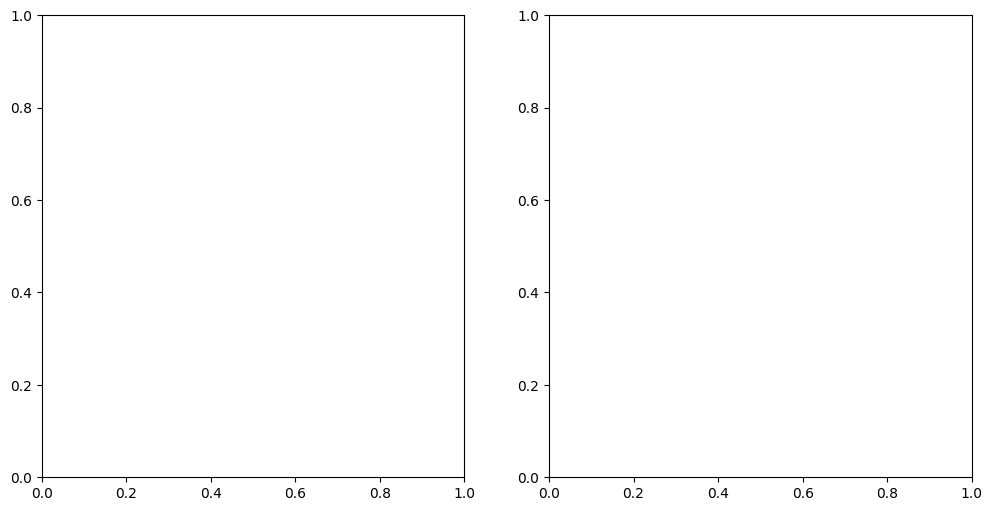

In [6]:
# ── 把 attention 向量 reshape 成图像 patch grid 并叠加到原图上 ────────────────
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def overlay_attention_on_image(image, attn_vec, ax, title):
    """将 1D attention 向量可视化为热图叠加在原图上。"""
    n = len(attn_vec)
    grid_size = int(np.sqrt(n))  # 假设是正方形 patch grid
    if grid_size * grid_size != n:
        # 非完美正方形，padding 到最近的整数
        grid_size = int(np.ceil(np.sqrt(n)))
        attn_padded = np.zeros(grid_size * grid_size)
        attn_padded[:n] = attn_vec
        attn_vec = attn_padded

    attn_grid = attn_vec.reshape(grid_size, grid_size)

    # 归一化到 [0,1]
    attn_grid = (attn_grid - attn_grid.min()) / (attn_grid.max() - attn_grid.min() + 1e-8)

    # 上采样到原图尺寸
    img_arr = np.array(image.convert('RGB').resize((336, 336)))
    heat = np.array(Image.fromarray((cm.hot(attn_grid)[:, :, :3] * 255).astype(np.uint8)).resize((336, 336)))
    blended = (0.5 * img_arr + 0.5 * heat).astype(np.uint8)

    ax.imshow(blended)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
overlay_attention_on_image(
    img_sarc, a_sarc, axes[0],
    f'讽刺\n"{txt_sarc[:50]}..."'
)
overlay_attention_on_image(
    img_nosarc, a_nosarc, axes[1],
    f'非讽刺\n"{txt_nosarc[:50]}..."'
)
plt.suptitle(f'文字 token → 图像 patch Attention 热图\n(Layer {best_layer}, Head {best_head})', fontsize=13)
plt.tight_layout()
plt.savefig('results/probing/attention_overlay.png', dpi=150)
plt.show()

## 7. 汇总

In [7]:
print('=' * 60)
print('LLaVA Cross-Modal Attention Probing — 结果汇总')
print('=' * 60)
print(f'模型:        {MODEL_ID}')
print(f'数据集:      MMSD 2.0 (各 {N_PER_CLASS} 样本)')
print(f'LLaMA 层数:  {num_layers}，Heads: {num_heads}')
print()
print(f'显著差异层 (p<0.05, 图→文): {sig_layers_i2t.tolist()}')
print(f'显著差异层 (p<0.05, 文→图): {sig_layers_t2i.tolist()}')
print()
print(f'差异最大的 Head (图→文): layer={top_i2t[0]}, head={top_i2t[1]}')
print(f'差异最大的 Head (文→图): layer={top_t2i[0]}, head={top_t2i[1]}')
print()
print('输出文件:')
print('  results/probing/cross_modal_attention_by_layer.png')
print('  results/probing/significance_by_layer.png')
print('  results/probing/head_diff_heatmap.png')
print('  results/probing/attention_overlay.png')
print('=' * 60)

LLaVA Cross-Modal Attention Probing — 结果汇总
模型:        llava-hf/llava-v1.6-mistral-7b-hf


NameError: name 'N_PER_CLASS' is not defined